# DATASCI 347 — Final Project Extension (Duration)

## Task 2: Predicting Control Relationship Duration

We extend the PSC project with a second ML task that is still grounded in `rels2.csv`, but is more learnable than control-type classification:

- For relationships that ended (have `ceased_on`), define duration:
  - `duration_days = ceased_on - notified_on`

We do two ML formulations:

1. Regression: predict `duration_days` (and `log1p(duration_days)` as a stabilized target).
   - Models: Ridge, Random Forest Regressor, Gradient Boosting Regressor
   - Metrics: MAE, RMSE, R²

2. Classification (bins): predict whether duration is short / medium / long.
   - short: ≤ 180 days
   - medium: (180, 730] days
   - long: > 730 days
   - Models: Multinomial Logistic Regression, Random Forest
   - Metrics: Accuracy, Macro F1 + confusion matrix

Features (known at the start of a relationship):
- `nature_primary` from `natures_of_control` (one-hot)
- `notified_year`, `notified_month` from `notified_on`

Outputs:
- `results/tables/duration_regression_results.csv`
- `results/tables/duration_classification_results.csv`
- `results/figures/` plots (pred vs actual, residuals, confusion matrix)

Local path used:
- rels2: `/Users/dw/Desktop/research/ch3_fixed_test/rels2.csv`


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier

os.makedirs("results/tables", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)

np.random.seed(347)

In [2]:
rels_path = r"/Users/dw/Desktop/research/ch3_fixed_test/rels2.csv" 

## 1) Load rels2.csv and build duration label

In [3]:
usecols = [":START_ID", ":END_ID", ":TYPE", "natures_of_control", "notified_on", "ceased_on"]
try:
    rels = pd.read_csv(rels_path, usecols=lambda c: c in usecols, low_memory=False)
except Exception:
    rels = pd.read_csv(rels_path, usecols=lambda c: c in usecols, encoding="latin1", low_memory=False)

rels = rels.dropna(subset=[":START_ID", ":END_ID"]).copy()
rels[":TYPE"] = rels[":TYPE"].fillna("CONTROLS")
rels = rels[rels[":TYPE"].astype(str).str.upper().eq("CONTROLS")].copy()

rels["notified_on"] = pd.to_datetime(rels["notified_on"], errors="coerce")
rels["ceased_on"] = pd.to_datetime(rels["ceased_on"], errors="coerce")

# ended relationships only (need both dates)
ended = rels.dropna(subset=["notified_on", "ceased_on"]).copy()
ended["duration_days"] = (ended["ceased_on"] - ended["notified_on"]).dt.days

# keep non-negative durations
ended = ended.loc[ended["duration_days"].notna() & (ended["duration_days"] >= 0)].copy()

ended.shape, ended["duration_days"].describe(percentiles=[0.1,0.25,0.5,0.75,0.9,0.95])

((4737, 7),
 count    4737.000000
 mean     1505.040321
 std      1014.983330
 min         0.000000
 10%       190.200000
 25%       633.000000
 50%      1365.000000
 75%      2297.000000
 90%      3012.400000
 95%      3269.000000
 max      3596.000000
 Name: duration_days, dtype: float64)

## 2) Features: control type + notified date

In [4]:
def primary_nature(x):
    if pd.isna(x):
        return "MISSING"
    s = str(x).strip()
    if not s:
        return "MISSING"
    parts = [p.strip() for p in re.split(r"[;|,]", s) if p.strip()]
    return parts[0] if parts else "MISSING"

ended["nature_primary"] = ended["natures_of_control"].apply(primary_nature)
ended["notified_year"] = ended["notified_on"].dt.year.astype(int)
ended["notified_month"] = ended["notified_on"].dt.month.astype(int)

X_time = ended[["notified_year", "notified_month"]].copy()
X_nature = pd.get_dummies(ended[["nature_primary"]].fillna("MISSING"), drop_first=True)
X = pd.concat([X_time, X_nature], axis=1).fillna(0)

y_days = ended["duration_days"].astype(float).values
y_log = np.log1p(y_days)

X.shape, y_days.mean(), np.median(y_days)

((4737, 29), 1505.040320878193, 1365.0)

## 3) Regression task: predict duration

We evaluate both on raw days and on log1p(days). Log target is usually easier because durations are skewed.

In [5]:
X_train, X_test, y_train_days, y_test_days, y_train_log, y_test_log = train_test_split(
    X.values, y_days, y_log,
    test_size=0.2, random_state=347
)

X_train.shape, X_test.shape

((3789, 29), (948, 29))

In [6]:
def reg_metrics(y_true, y_pred):
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))
    return mae, rmse, r2

In [7]:
# Models
ridge = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("model", Ridge(alpha=10.0, random_state=347))
])

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=347,
    n_jobs=1,
    max_features="sqrt"
)

gbr = GradientBoostingRegressor(
    random_state=347,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3
)

models = {
    "Ridge": ridge,
    "RF": rf,
    "GBR": gbr
}

rows = []
pred_store = {}

for name, m in models.items():
    m.fit(X_train, y_train_log)
    pred_log = m.predict(X_test)
    pred_days = np.expm1(pred_log)
    pred_days[pred_days < 0] = 0.0

    mae, rmse, r2 = reg_metrics(y_test_days, pred_days)
    rows.append({"model": name, "MAE_days": mae, "RMSE_days": rmse, "R2_days": r2})
    pred_store[name] = pred_days

reg_res = pd.DataFrame(rows).sort_values("RMSE_days")
reg_res

,model,MAE_days,RMSE_days,R2_days
2,GBR,859.426523,1099.249128,-0.205282
0,Ridge,862.321019,1100.592045,-0.208229
1,RF,872.194612,1109.908458,-0.228771


### Regression plots (best model)

We plot predicted vs actual duration (days) and residuals for the best model by RMSE.

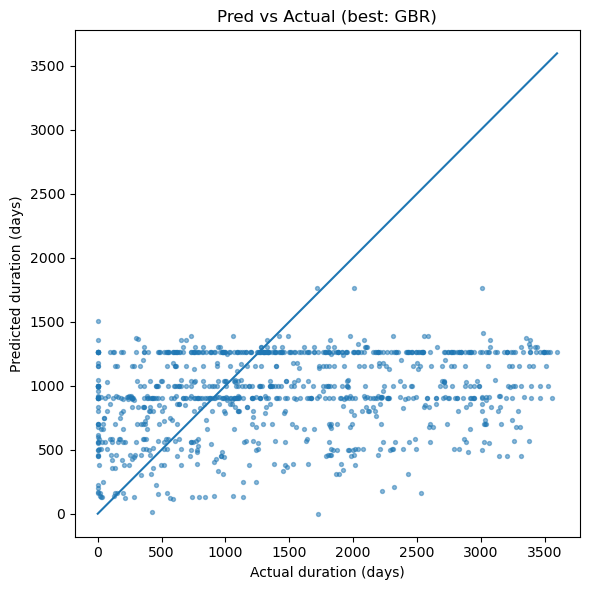

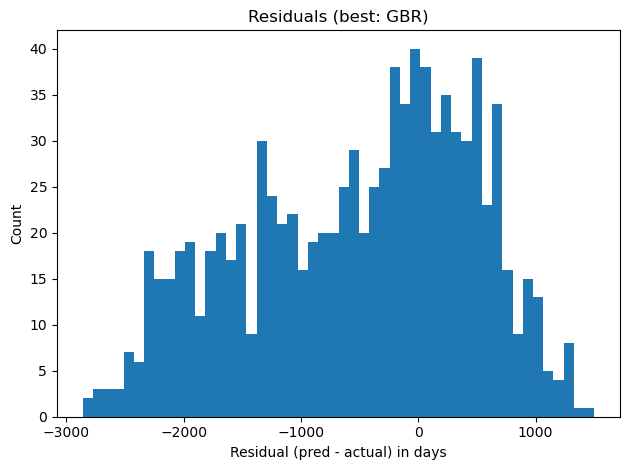

In [8]:
best_model_name = reg_res.iloc[0]["model"]
best_pred = pred_store[best_model_name]

plt.figure(figsize=(6,6))
plt.scatter(y_test_days, best_pred, s=8, alpha=0.5)
mx = max(y_test_days.max(), best_pred.max())
plt.plot([0, mx], [0, mx])
plt.xlabel("Actual duration (days)")
plt.ylabel("Predicted duration (days)")
plt.title(f"Pred vs Actual (best: {best_model_name})")
plt.tight_layout()
plt.savefig("results/figures/duration_pred_vs_actual.png", dpi=200)
plt.show()

resid = best_pred - y_test_days
plt.figure()
plt.hist(resid, bins=50)
plt.xlabel("Residual (pred - actual) in days")
plt.ylabel("Count")
plt.title(f"Residuals (best: {best_model_name})")
plt.tight_layout()
plt.savefig("results/figures/duration_residuals_hist.png", dpi=200)
plt.show()

## 4) Classification task: short / medium / long

Define bins:
- short: ≤ 180 days
- medium: (180, 730] days
- long: > 730 days

In [9]:
def bin_duration(d):
    if d <= 180:
        return "short"
    if d <= 730:
        return "medium"
    return "long"

y_bin = np.array([bin_duration(d) for d in y_days], dtype=object)
pd.Series(y_bin).value_counts(normalize=True)

long      0.718387
medium    0.185349
short     0.096263
Name: proportion, dtype: float64

In [10]:
Xtr, Xte, ytr, yte = train_test_split(
    X.values, y_bin,
    test_size=0.2, random_state=347, stratify=y_bin
)

# Multinomial logreg (balanced)
clf_lr = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=8000,
        class_weight="balanced"
    ))
])

clf_rf = RandomForestClassifier(
    n_estimators=600,
    random_state=347,
    n_jobs=1,
    max_features="sqrt",
    class_weight="balanced_subsample"
)

clf_lr.fit(Xtr, ytr)
pred_lr = clf_lr.predict(Xte)

clf_rf.fit(Xtr, ytr)
pred_rf = clf_rf.predict(Xte)

def cls_metrics(y_true, y_pred):
    return float(accuracy_score(y_true, y_pred)), float(f1_score(y_true, y_pred, average="macro"))

acc_lr, f1_lr = cls_metrics(yte, pred_lr)
acc_rf, f1_rf = cls_metrics(yte, pred_rf)

pd.DataFrame([
    {"model":"LogReg_balanced", "accuracy": acc_lr, "macro_f1": f1_lr},
    {"model":"RF_balanced", "accuracy": acc_rf, "macro_f1": f1_rf},
]).sort_values("macro_f1", ascending=False)

,model,accuracy,macro_f1
1,RF_balanced,0.598101,0.440150
0,LogReg_balanced,0.411392,0.293933


### Classification reports + confusion matrices

In [11]:
print("LogReg report")
print(classification_report(yte, pred_lr))
print("RF report")
print(classification_report(yte, pred_rf))

LogReg report
              precision    recall  f1-score   support

        long       0.75      0.48      0.59       681
      medium       0.23      0.08      0.12       176
       short       0.11      0.53      0.18        91

    accuracy                           0.41       948
   macro avg       0.36      0.36      0.29       948
weighted avg       0.59      0.41      0.46       948

RF report
              precision    recall  f1-score   support

        long       0.80      0.70      0.75       681
      medium       0.29      0.31      0.30       176
       short       0.22      0.37      0.27        91

    accuracy                           0.60       948
   macro avg       0.43      0.46      0.44       948
weighted avg       0.65      0.60      0.62       948



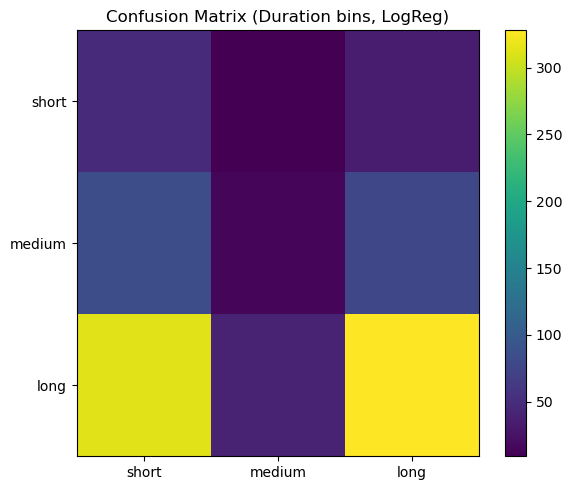

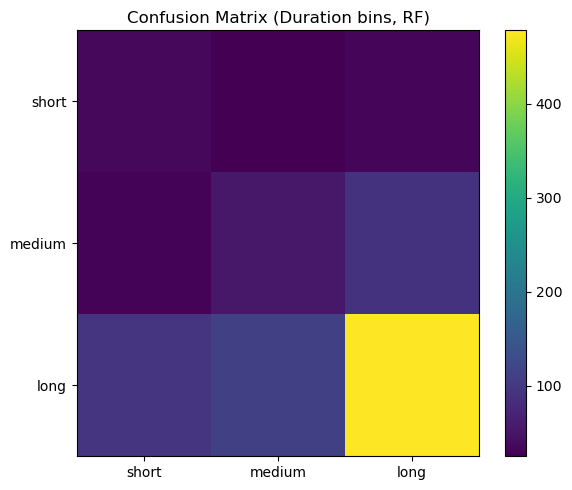

In [12]:
labels = ["short","medium","long"]

cm_lr = confusion_matrix(yte, pred_lr, labels=labels)
cm_rf = confusion_matrix(yte, pred_rf, labels=labels)

def plot_cm(cm, labels, title, out_png):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, aspect="auto")
    plt.xticks(range(len(labels)), labels)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.show()

plot_cm(cm_lr, labels, "Confusion Matrix (Duration bins, LogReg)", "results/figures/duration_bins_cm_logreg.png")
plot_cm(cm_rf, labels, "Confusion Matrix (Duration bins, RF)", "results/figures/duration_bins_cm_rf.png")

## 5) Save tables

In [13]:
reg_res.to_csv("results/tables/duration_regression_results.csv", index=False)

cls_res = pd.DataFrame([
    {"task":"duration_bins", "model":"LogReg_balanced", "accuracy": acc_lr, "macro_f1": f1_lr},
    {"task":"duration_bins", "model":"RF_balanced", "accuracy": acc_rf, "macro_f1": f1_rf},
]).sort_values("macro_f1", ascending=False)

cls_res.to_csv("results/tables/duration_classification_results.csv", index=False)

pd.Series({
    "n_total_edges": len(rels),
    "n_ended_edges": len(ended),
    "ended_rate_in_edges": float(len(ended)/len(rels))
}).to_csv("results/tables/duration_data_summary.csv")

reg_res, cls_res

(   model    MAE_days    RMSE_days   R2_days
 2    GBR  859.426523  1099.249128 -0.205282
 0  Ridge  862.321019  1100.592045 -0.208229
 1     RF  872.194612  1109.908458 -0.228771,
             task            model  accuracy  macro_f1
 1  duration_bins      RF_balanced  0.598101  0.440150
 0  duration_bins  LogReg_balanced  0.411392  0.293933)